In [1]:
import sys
from pathlib import Path

# Add project root to Python path
sys.path.append(str(Path.cwd().parent))

from generate_greedy_training_set import *

%matplotlib inline

# Simulating inspirals

To have a look at all the specifics of the class (parameters, units, defualt values), run the cell below

In [2]:
Simulate_Waveform?

Init signature:
Simulate_Waveform(
    time_array,
    f_lower=10,
    f_ref=20,
    ecc_ref=None,
    mean_anomaly_ref=0.0,
    total_mass=None,
    luminosity_distance=None,
    mass_ratio=1,
    chi1=0,
    chi2=0,
    phiRef=0.0,
    inclination=0.0,
    truncate_at_ISCO=True,
    truncate_at_tmin=True,
    geometric_units=True,
)
Docstring:      Simulates time-domain (2,2) mode EOB waveform of a binary blackhole merger. Generates time-domain from starting frequency (f_lower) till peak at t=0 for time in geometric units. 
Init docstring:
Parameters:
----------------
time_array [s], np.array : Time array in seconds.
ecc_ref [dimensionless], float: Eccentricity of binary at start f_lower
mean_anomaly_ref [rad], float : Mean anomaly at reference frequency f_ref
total_mass [M_sun], int : Total mass of the binary in solar masses. =None for geometric units
luminosity_distance [Mpc], float : Luminosity distance of the binary in megaparsec. =None for geometric units
mass_ratio [dimensionle

For now let's start with a simple example, only including time-array and eccentricity.

`truncate_at_tmin=True` means that the time-array gets cut uptil the point of physical inspiral. Some events have a shorter inspiral than other (highest eccentricity gives the shortest inspiral time), so the time-array of teh entire created dataset is cut to the shortest time-domain waveform.

`truncate_at_ISCO=True` means that the time-domain is cut at the transition from inspiral to merger, so merger and ringdown phase will be cut. The IMRPhenomTEHM model assumes that the binary has circulized before merger (which is defined at t=0), so the final part can act slightly strange. For modeling purposes it is easier to for now to cut to ISCO. 

while defining the class and calling it's functions, the class has a consistent overall structure where class wide parameters need to be defined in the creation of the class object (`Simulate_Waveform(time_array=time_array, ...)`). If you call a specififc function with specific parameter definitions, the function will use the defined parameters. If nothing is specified, it will default to the class instance variables. 

For example:
`sw = Simulate_Waveform(total_mass=60)`
`sw.simulate_waveform()`

will be using 60M, but for:

`sw = Simulate_Waveform(total_mass=60)`
`sw.simulate_waveform()`

will be using 80M

Set `geometric_units=False` if you want the output to be in SI units. For SI units, you NEED to pass mass_ratio and luminosity_distance or it doesn't work. In case of geometric units, a reference mass of 60M is used under the hood for the computations in IMRPhenomTEHM.

In [3]:
# Sampling parameters
sampling_frequency = 2048 # or 4096
duration = 4 # seconds
time_array = np.linspace(-duration, 0, int(sampling_frequency * duration))  # time in seconds


To simulate a waveform from the IMRPhenomTEHM package, this is very straightforward:

In [4]:
sw = Simulate_Waveform(
    time_array=time_array,
    mass_ratio=1,
    chi1=0,
    chi2=0,
    ecc_ref=0.2,        
    f_ref=20,            # in Hz
    f_lower=10,          # in Hz
    phiRef=0,           # in radians
    inclination=0,      # in radians
    mean_anomaly_ref=0,     # in radians
)   

/media/suzanne/026e7495-c318-4ea6-965f-eac8ffddc6af/suzanne/Python_scripts/SurrogateModel_3PN_eccentric/phenomxpy/my_project/generate_PhenomTE.py:251: UserWarning: t_min is larger than parts of the specified time-domain, resulting in unphysical waveforms. Either use the truncate_at_tmin=True setting to automatically truncate to physical start of the time-domain or adjust the time-array manually to start at higher values.
  warnings.warn(self.colored_text(


NEW TIME-DOMAIN after truncate at tmin (in geometric units): [-12697, 0] M
NEW TIME-DOMAIN after truncate at ISCO (in geometric units): [-12697, -76] M
Figure is saved in Images/Polarisations/Polarisations_M=None_ecc_ref=0.2_mean_ano_ref=0_q=1.png
NEW TIME-DOMAIN after truncate at tmin (in geometric units): [-12697, 0] M
NEW TIME-DOMAIN after truncate at ISCO (in geometric units): [-12697, -76] M
Figure is saved in Images/Polarisations/Polarisations_M=60_ecc_ref=0.2_mean_ano_ref=0_q=1.png


(array([ 2.65780372e-23,  2.39520015e-23,  2.12924945e-23, ...,
        -1.51300261e-22, -3.48052504e-22, -5.29714474e-22], shape=(7639,)),
 array([1.31517914e-22, 1.32412785e-22, 1.33259625e-22, ...,
        9.05607153e-22, 8.52599623e-22, 7.56720418e-22], shape=(7639,)),
 array([-3.75241118, -3.75192284, -3.7514345 , ..., -0.02344036,
        -0.02295202, -0.02246368], shape=(7639,)))

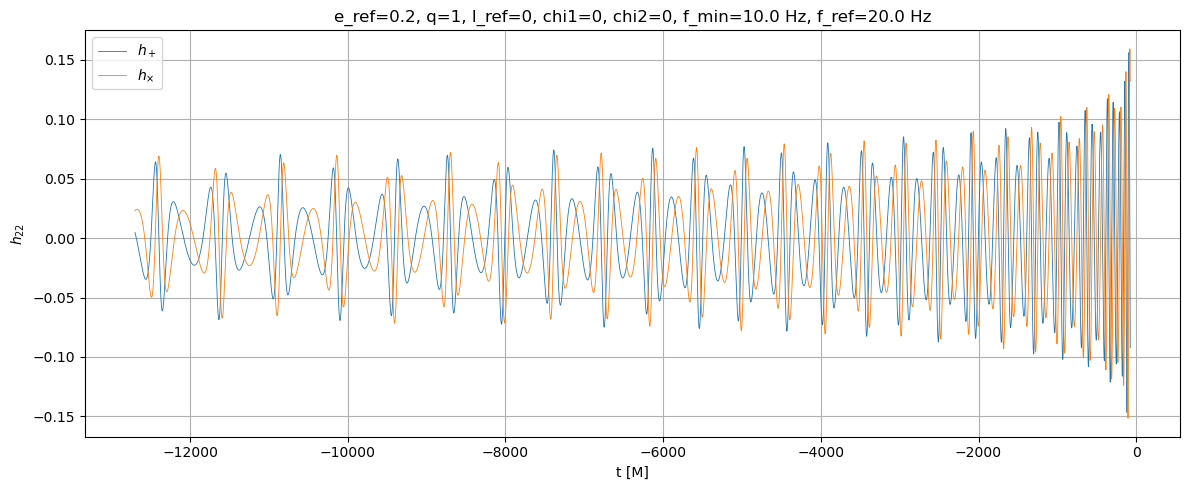

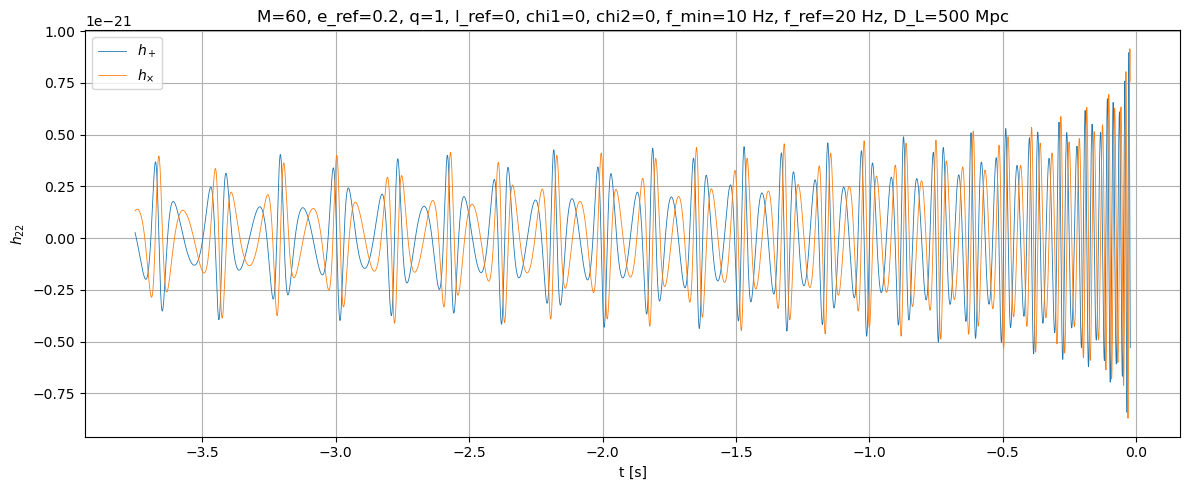

In [5]:
sw.simulate_waveform(geometric_units=True, truncate_at_ISCO=True, truncate_at_tmin=True, plot_polarisations=True, save_fig_polarisations=True)
sw.simulate_waveform(geometric_units=False, total_mass=60, luminosity_distance=500, truncate_at_ISCO=True, truncate_at_tmin=True, plot_polarisations=True, save_fig_polarisations=True)

# Training set generation

In [6]:
Generate_TrainingSet?

Init signature:
Generate_TrainingSet(
    time_array,
    ecc_ref_parameterspace=array([0.        , 0.0030303 , 0.00606061, 0.00909091, 0.01212121,
       0.01515152, 0.01818182, 0.02121212, 0.02424242, 0.02727273,
       0.03030303, 0.03333333, 0.03636364, 0.03939394, 0.04242424,
       0.04545455, 0.04848485, 0.05151515, 0.05454545, 0.05757576,
       0.06060606, 0.06363636, 0.06666667, 0.06969697, 0.07272727,
       0.07575758, 0.07878788, 0.08181818, 0.08484848, 0.08787879,
       0.09090909, 0.09393939, 0.0969697 , 0.1       , 0.1030303 ,
       0.10606061, 0.10909091, 0.11212121, 0.11515152, 0.11818182,
       0.12121212, 0.12424242, 0.12727273, 0.13030303, 0.13333333,
       0.13636364, 0.13939394, 0.14242424, 0.14545455, 0.14848485,
       0.15151515, 0.15454545, 0.15757576, 0.16060606, 0.16363636,
       0.16666667, 0.16969697, 0.17272727, 0.17575758, 0.17878788,
       0.18181818, 0.18484848, 0.18787879, 0.19090909, 0.19393939,
       0.1969697 , 0.2       , 0.2030303 , 0.206

You can choose to run the greedy algorithm with 2 different stopping criteria:
- Based on the maximum amount of residuals in the greedy basis. For example, set `N_basis_vecs_amp = 50` and your reduced basis will stop generating at 50 greedy points.
- Based on the minimum greedy error. Set `min_greedy_error_phase = 1e-6` and the greedy algorithm will stop generating once it's reached the greedy error specified. 

The amount of greedy points and empirical nodes will always have the same size. This needs to be true, because the training set needs to be a square-matrix for later calculations.

In [7]:
ecc_ref_space=np.linspace(0.001, 0.3, num=200)
mean_ano_ref_space = [0]
mass_ratio_space = [1]
chi1_space = [0]
chi2_space = [0]

# Example with max 50 basis vectors for amplitude and phase
gt = Generate_TrainingSet(time_array=time_array, 
                          ecc_ref_parameterspace=ecc_ref_space, 
                          mean_ano_parameterspace=mean_ano_ref_space, 
                          mass_ratio_parameterspace=mass_ratio_space, 
                          chi1_parameterspace=chi1_space, 
                          chi2_parameterspace=chi2_space, 
                          N_basis_vecs_amp=50, 
                          N_basis_vecs_phase=50,
                          truncate_at_ISCO=True, 
                          truncate_at_tmin=True)


Residual dataset found and loaded: Straindata/Residuals/residuals_amplitude_e=[0.001_0.3_N=200]_l=[0_0_N=1]_q=[1_1_N=1]_x1=[0_0_N=1]_x2=[0_0_N=1]_fr=20_fl=10_Nb=50.npz
Figure is saved in Images/Greedy_errors/Greedy_error_amplitude_e=[0.001_0.3_N=200]_l=[0_0_N=1]_q=[1_1_N=1]_x1=[0_0_N=1]_x2=[0_0_N=1]_fr=20_fl=10_Nb=50.png
Figure is saved in Images/Empirical_nodes/RB_functions_with_emp_nodes_leaf_0_amplitude_e=[0.001_0.3_N=200]_l=[0_0_N=1]_q=[1_1_N=1]_x1=[0_0_N=1]_x2=[0_0_N=1]_fr=20_fl=10_Nb=50.png
Figure is saved in Images/TrainingSet/Training_set_amplitude_e=[0.001_0.3_N=200]_l=[0_0_N=1]_q=[1_1_N=1]_x1=[0_0_N=1]_x2=[0_0_N=1]_fr=20_fl=10_Nb=50.png


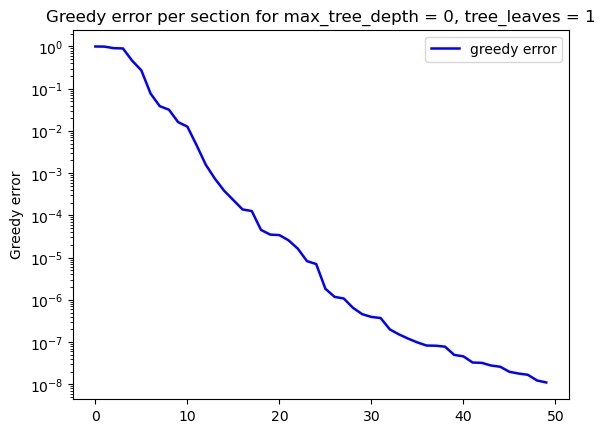

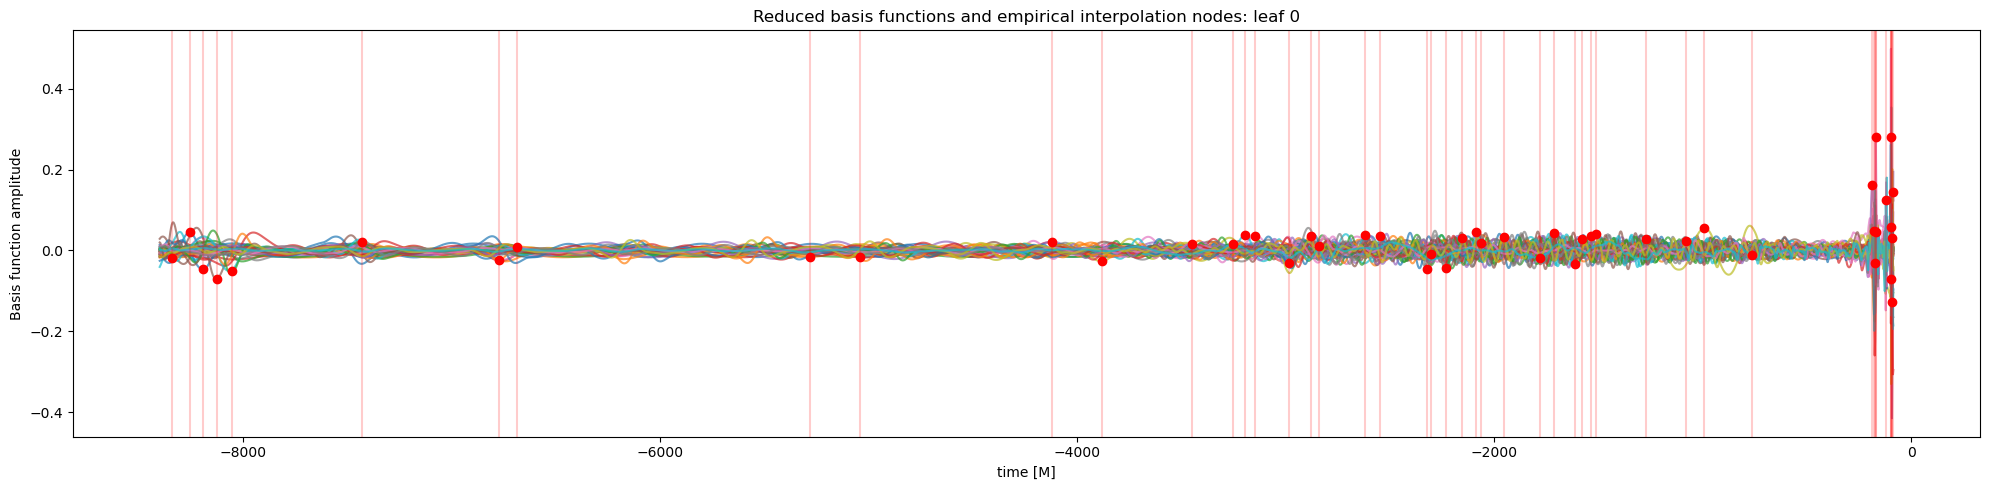

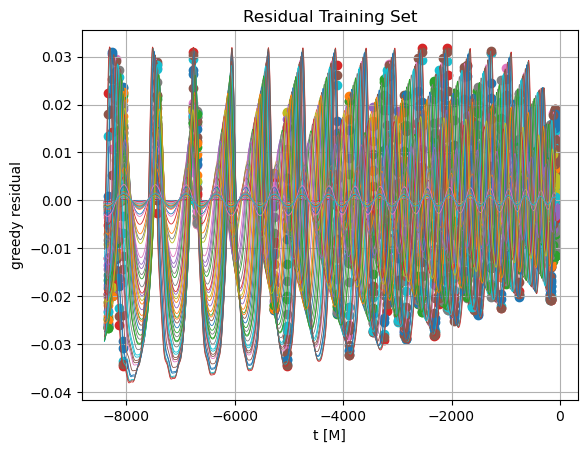

In [8]:
train_amp = gt.get_training_set_greedy(
    property='amplitude', 
    plot_training_set=True, 
    save_fig_training_set=True,
    plot_emp_nodes_on_basis=True,
    save_fig_emp_nodes_on_basis=True,
    plot_greedy_error=True,
    save_fig_greedy_error=True,
    )

plt.show()

In [9]:
train_amp?

# For example
print(train_amp.residuals, train_amp.basis_indices, train_amp.empirical_indices, train_amp.training_set)

[[-8.87688496e-05 -8.98278894e-05 -9.08598346e-05 ...  4.36103555e-05
   4.23466816e-05  4.05128984e-05]
 [-2.22556042e-04 -2.25184669e-04 -2.27745841e-04 ...  1.02937877e-04
   1.00379299e-04  9.49292984e-05]
 [-3.56872275e-04 -3.61047007e-04 -3.65114263e-04 ...  1.63580036e-04
   1.61072294e-04  1.54974050e-04]
 ...
 [-1.27293732e-02 -1.22405019e-02 -1.17338859e-02 ...  1.39464415e-02
   1.45384800e-02  1.50845796e-02]
 [-1.02143049e-02 -9.62819807e-03 -9.02368092e-03 ...  1.21044623e-02
   1.27731755e-02  1.34007991e-02]
 [-7.07812747e-03 -6.39102617e-03 -5.68654509e-03 ...  1.02703334e-02
   1.09953837e-02  1.16876338e-02]] [0, 124, 165, 199, 84, 146, 184, 105, 54, 175, 193, 136, 156, 30, 115, 189, 71, 170, 3, 197, 151, 11, 96, 1, 130, 180, 2, 160, 9, 4, 194, 42, 140, 112, 10, 182, 5, 91, 6, 177, 17, 142, 164, 7, 79, 198, 20, 49, 120, 8] [np.int64(35), np.int64(1888), np.int64(3116), np.int64(2033), np.int64(2590), np.int64(4127), np.int64(3179), np.int64(4429), np.int64(2734), np.

Type:        TrainingSetParameters
String form:
TrainingSetParameters(property='amplitude', e=array([0.001 , 0.0025, 0.004 , 0.0055, 0.007 , 0.00 <...> 736e-04, ...,
           1.29085311e-03,  1.08589891e-04,  6.53544089e-04]],
           shape=(50, 50)))
File:        /media/suzanne/026e7495-c318-4ea6-965f-eac8ffddc6af/suzanne/Python_scripts/SurrogateModel_3PN_eccentric/phenomxpy/my_project/generate_greedy_training_set.py
Docstring:  
Dataclass to store the parameters and results of the greedy algorithm for a training set.
Attributes:
property [str]: the property for which the greedy algorithm is applied ("phase" or "amplitude")
e [np.ndarray]: eccentricities of the dataset used for reduced basis construction
l [np.ndarray]: mean anomalies of the dataset used for reduced basis construction
q [np.ndarray]: mass ratios of the dataset used for reduced basis construction
chi1 [np.ndarray]: dimensionless spin of the primary black hole
chi2 [np.ndarray]: dimensionless spin of the secondary 

Residual dataset found and loaded: Straindata/Residuals/residuals_phase_e=[0.001_0.3_N=200]_l=[0_0_N=1]_q=[1_1_N=1]_x1=[0_0_N=1]_x2=[0_0_N=1]_fr=20_fl=10_Nb=50.npz
Figure is saved in Images/Greedy_errors/Greedy_error_phase_e=[0.001_0.3_N=200]_l=[0_0_N=1]_q=[1_1_N=1]_x1=[0_0_N=1]_x2=[0_0_N=1]_fr=20_fl=10_Nb=50.png
Figure is saved in Images/Empirical_nodes/RB_functions_with_emp_nodes_leaf_0_phase_e=[0.001_0.3_N=200]_l=[0_0_N=1]_q=[1_1_N=1]_x1=[0_0_N=1]_x2=[0_0_N=1]_fr=20_fl=10_Nb=50.png
Figure is saved in Images/TrainingSet/Training_set_phase_e=[0.001_0.3_N=200]_l=[0_0_N=1]_q=[1_1_N=1]_x1=[0_0_N=1]_x2=[0_0_N=1]_fr=20_fl=10_Nb=50.png


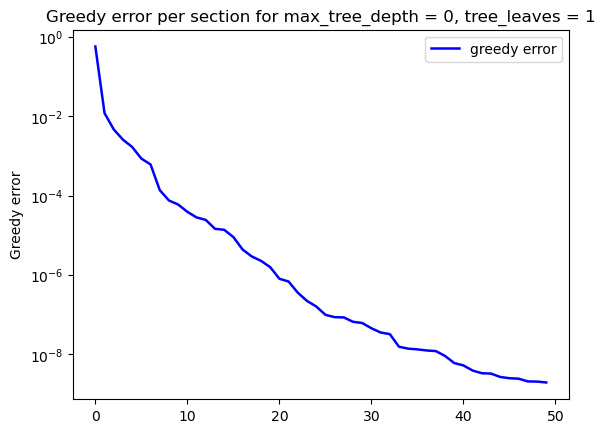

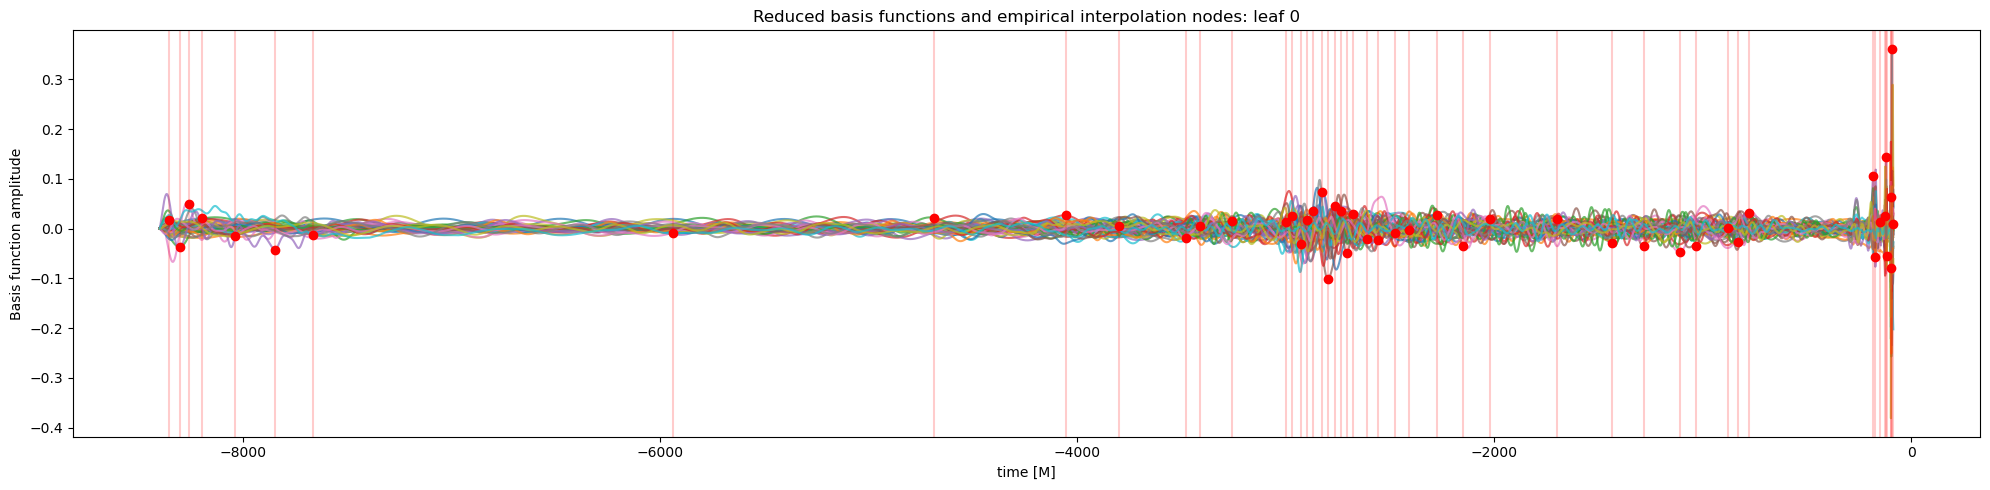

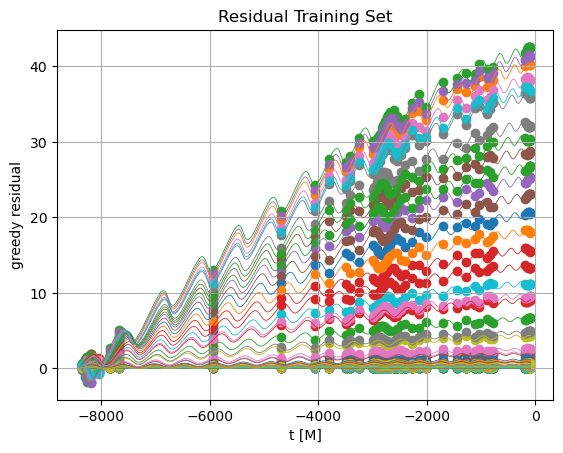

In [10]:
# Same for phase
train_amp = gt.get_training_set_greedy(
    property='phase', 
    plot_training_set=True, 
    save_fig_training_set=True,
    plot_emp_nodes_on_basis=True,
    save_fig_emp_nodes_on_basis=True,
    plot_greedy_error=True,
    save_fig_greedy_error=True,
    )

plt.show()

Below an example of running the greedy algortihm for a specified `min_greedy_error`

Residual dataset found and loaded: Straindata/Residuals/residuals_amplitude_e=[0.001_0.3_N=200]_l=[0_0_N=1]_q=[1_1_N=1]_x1=[0_0_N=1]_x2=[0_0_N=1]_fr=20_fl=10_gerr=1e-08.npz
Figure is saved in Images/Greedy_errors/Greedy_error_amplitude_e=[0.001_0.3_N=200]_l=[0_0_N=1]_q=[1_1_N=1]_x1=[0_0_N=1]_x2=[0_0_N=1]_fr=20_fl=10_gerr=1e-08.png
Residual dataset found and loaded: Straindata/Residuals/residuals_phase_e=[0.001_0.3_N=200]_l=[0_0_N=1]_q=[1_1_N=1]_x1=[0_0_N=1]_x2=[0_0_N=1]_fr=20_fl=10_gerr=1e-08.npz
Figure is saved in Images/Greedy_errors/Greedy_error_phase_e=[0.001_0.3_N=200]_l=[0_0_N=1]_q=[1_1_N=1]_x1=[0_0_N=1]_x2=[0_0_N=1]_fr=20_fl=10_gerr=1e-08.png
(51, 51) (39, 39)


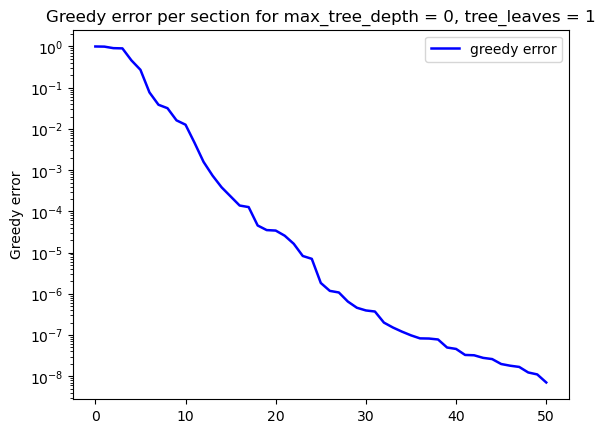

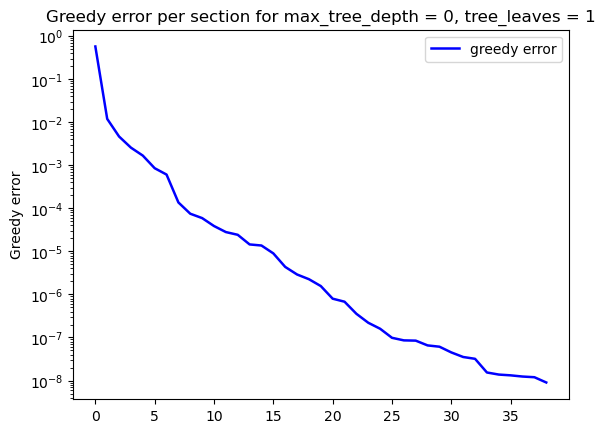

In [13]:
gt_err = Generate_TrainingSet(time_array=time_array, 
                          ecc_ref_parameterspace=ecc_ref_space, 
                          mean_ano_parameterspace=mean_ano_ref_space, 
                          mass_ratio_parameterspace=[1], 
                          chi1_parameterspace=[0], 
                          chi2_parameterspace=[0], 
                          min_greedy_error_amp=1e-8, 
                          min_greedy_error_phase=1e-8,
                          truncate_at_ISCO=True, 
                          truncate_at_tmin=True)

train_amp = gt_err.get_training_set_greedy(
    property='amplitude', 
    plot_greedy_error=True,
    save_fig_greedy_error=True,
    )

train_phase = gt_err.get_training_set_greedy(
    property='phase', 
    plot_greedy_error=True,
    save_fig_greedy_error=True,
    )

print(train_amp.training_set.shape, train_phase.training_set.shape)